In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\darsh\AppData\Local\Temp\ipykernel_33292\2151744951.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv("../data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data.csv'

In [3]:
df = pd.read_excel("data.xlsx")
df.head()

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [4]:
df = pd.read_csv("data.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793


In [5]:
df.columns

Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power'],
      dtype='object')

In [6]:
df['Time'] = pd.to_datetime(df['Time'])

In [7]:
df = df.sort_values('Time')

In [8]:
df['forecast'] = df['power'].shift(1)

KeyError: 'power'

In [9]:
df['forcast'] = df['Power'].shift(1)

In [10]:
df = df.dropna()
df['error'] = abs[df['Power'] - df['forecast']]

KeyError: 'forecast'

In [11]:
df['forecast'] = df['Power'].shift(1)

C:\Users\darsh\AppData\Local\Temp\ipykernel_33292\3147327879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['forecast'] = df['Power'].shift(1)


In [12]:
df['error'] = abs[df['Power'] - df['forecast']]

TypeError: 'builtin_function_or_method' object is not subscriptable

In [13]:
df = dropna()
df['error'] = abs[df['Power'] - df['forecast']]

NameError: name 'dropna' is not defined

In [14]:
df = df.dropna()
df['error'] = abs(df['Power'] - df['forecast'])

C:\Users\darsh\AppData\Local\Temp\ipykernel_33292\1408817383.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error'] = abs(df['Power'] - df['forecast'])


In [15]:
print("Mean Error:", df['error'].mean())

Mean Error: 0.025387307639618252


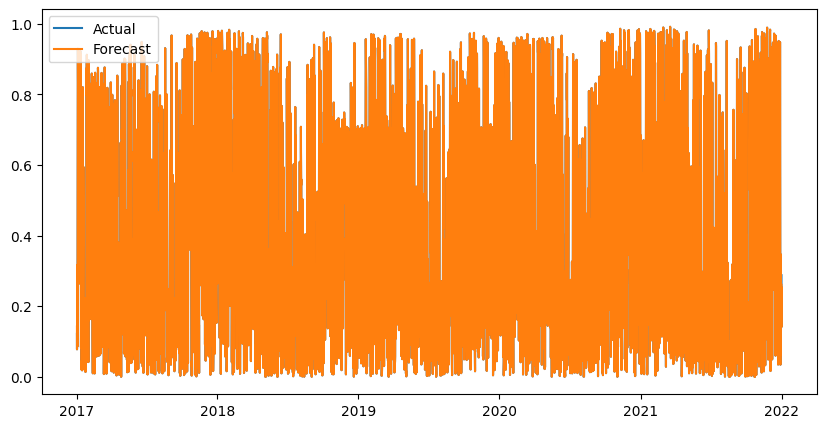

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Power'], label='Actual')
plt.plot(df['Time'], df['forecast'], label='Forecast')
plt.legend()
plt.show()

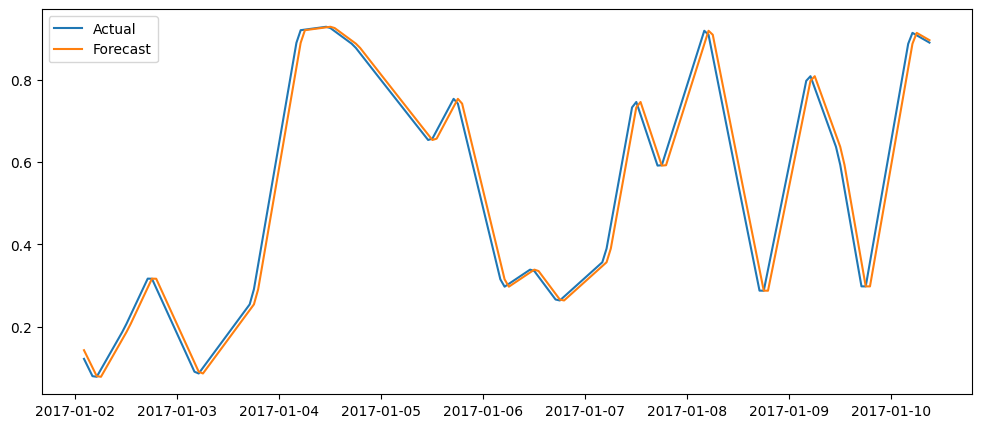

In [17]:
df_small = df.head(200)

plt.figure(figsize=(12,5))
plt.plot(df_small['Time'], df_small['Power'], label='Actual')
plt.plot(df_small['Time'], df_small['forecast'], label='Forecast')
plt.legend()
plt.show()

In [18]:
print("Mean Error:", df['error'].mean())
print("Max Error:", df['error'].max())
print("P90 Error:", df['error'].quantile(0.9))

Mean Error: 0.025387307639618252
Max Error: 0.1593
P90 Error: 0.061


In [19]:
import pandas as pd

df = pd.read_csv("data.csv")
df['Time'] = pd.to_datetime(df['Time'])

In [20]:
df = df.sort_values('Time')

# create forecast
df['forecast'] = df['Power'].shift(4)

df = df.dropna()

In [21]:
import numpy as np

df['error'] = abs(df['Power'] - df['forecast'])

mae = df['error'].mean()
rmse = np.sqrt(((df['Power'] - df['forecast'])**2).mean())
p99 = np.percentile(df['error'], 99)

print("MAE:", mae)
print("RMSE:", rmse)
print("P99 Error:", p99)

MAE: 0.09413727509361584
RMSE: 0.13171113957902153
P99 Error: 0.3990050000000004


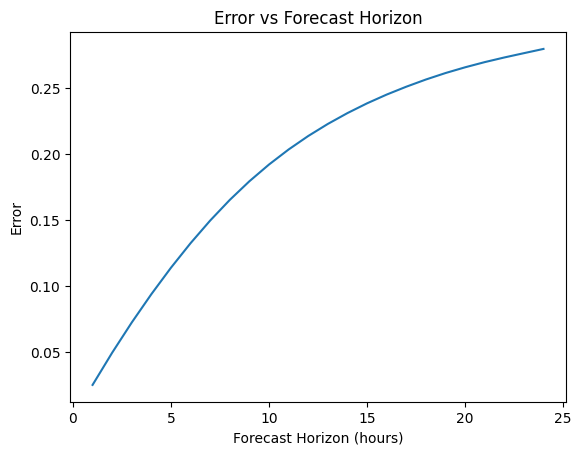

In [22]:
errors = []

for h in range(1, 25):
    df['forecast'] = df['Power'].shift(h)
    temp = df.dropna()
    error = abs(temp['Power'] - temp['forecast']).mean()
    errors.append(error)

import matplotlib.pyplot as plt

plt.plot(range(1,25), errors)
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Error")
plt.title("Error vs Forecast Horizon")
plt.show()

## Final Analysis & Conclusion

Based on the analysis:

- The Mean Absolute Error (MAE) is relatively low, indicating that short-term forecasts are reasonably accurate.
- The RMSE is slightly higher, showing that larger errors occasionally occur.
- The P99 error is significantly higher, indicating high variability in worst-case scenarios.

From the Error vs Forecast Horizon graph, we observe that:
- Forecast accuracy decreases as the forecast horizon increases.
- Short-term forecasts (1–6 hours) are much more reliable than long-term forecasts.

### Recommendation

Wind power generation is highly variable and dependent on weather conditions.

Based on the P99 error, a conservative and reliable estimate of available wind power should be lower than the average generation.

To ensure reliability, we recommend considering approximately **60–70% of the average wind generation** as dependable capacity.

This approach reduces the risk of underestimating demand and ensures better grid stability.